# 04 · Search and decisions: bandits, UCT and Monte Carlo tree search

### A visual laboratory for deciding where the next computation should go

In **02**, candidate programs became executable hypotheses. In **03**, we compared existing hypotheses using Bayesian reasoning, MDL, and uncertainty. Here we cannot enumerate every candidate: **how should limited computation be allocated to promising branches?**

We construct bandits, UCB1, explicit program trees, and MCTS using NumPy and Matplotlib alone. We visualize exploration, revisit counts, tree credit assignment, sparse rewards, and computational costs.

**Reading practice:** predict before running; inspect each plotted result; change parameters and rerun from top. The demonstrations use synthetic rewards, not ARC benchmark tasks.

**Core distinction:** posterior probability that an explanation is true (03) is *not* automatically the estimated return from choosing a search action (04).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from itertools import product
SEED=4026
np.set_printoptions(precision=3,suppress=True)
plt.rcParams.update({'figure.figsize':(9,3.8),'axes.grid':True,'grid.alpha':0.2})
print('Ready: NumPy and Matplotlib only.')

Ready: NumPy and Matplotlib only.


## 1 · The finite-budget problem

Imagine four candidate operations with unknown probabilities of producing an immediately useful result. We have a fixed evaluation budget. **Uniform** allocation ignores observations; **greedy** selection can lock onto a lucky observation; **optimistic** selection explores uncertain actions.

Each arm yields an independent Bernoulli reward only for this controlled example. Real grammar-search rewards may depend on the task, the source phenotype, and the current program.

**Predict:** Could a low-quality arm produce more successes than the best arm in its first five trials?

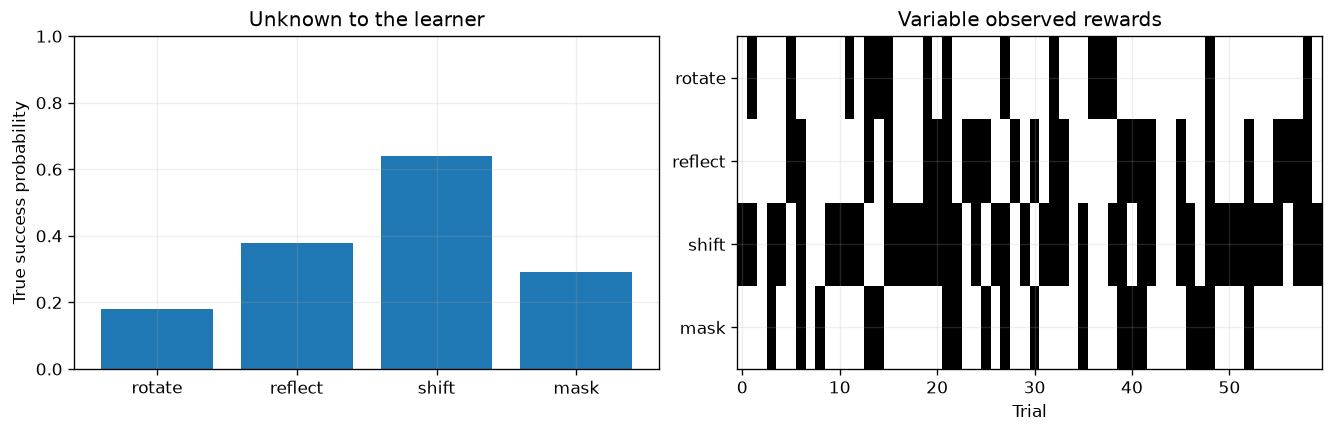

In [2]:
NAMES=['rotate','reflect','shift','mask']
P=np.array([.18,.38,.64,.29])
rng=np.random.default_rng(SEED)
draws=rng.binomial(1,P,(60,4))
fig,ax=plt.subplots(1,2,figsize=(11,3.5),layout='constrained')
ax[0].bar(NAMES,P);ax[0].set(ylim=(0,1),ylabel='True success probability',title='Unknown to the learner')
ax[1].imshow(draws.T,aspect='auto',cmap='Greys',vmin=0,vmax=1,interpolation='nearest')
ax[1].set(yticks=range(4),yticklabels=NAMES,xlabel='Trial',title='Variable observed rewards')
plt.show()

## 2 · UCB1: exploitation plus an exploration bonus

For each arm, store number of evaluations $n_i$ and empirical reward average $\hat\mu_i$. After sampling each arm once, UCB1 chooses the arm maximizing

$$U_i(t)=\hat\mu_i+\sqrt{\frac{2\ln t}{n_i}}.$$

The first term favors observed performance; the second favors insufficiently sampled arms. This classic expression is motivated by bounded, stationary, independent reward assumptions. **It is not a calibrated posterior probability.**

**Predict:** At equal means, which arm has the larger UCB score: 2 visits or 20?

In [3]:
def choose_arm(policy,n,total_reward,rng,C=np.sqrt(2)):
    k=len(n)
    if policy=='uniform': return int(rng.integers(k))
    unseen=np.flatnonzero(n==0)
    if len(unseen): return int(unseen[0])
    mean=total_reward/n
    if policy=='greedy':return int(np.argmax(mean))
    if policy=='ucb':return int(np.argmax(mean+C*np.sqrt(np.log(n.sum())/n)))
    raise ValueError(policy)

def run_bandit(policy,probs,horizon=120,seed=0,C=np.sqrt(2)):
    rng=np.random.default_rng(seed)
    n=np.zeros(len(probs),dtype=int);reward_sum=np.zeros(len(probs))
    selections=[];regret=[];rewards=[]
    for step in range(horizon):
        arm=choose_arm(policy,n,reward_sum,rng,C)
        reward=float(rng.random()<probs[arm])
        n[arm]+=1;reward_sum[arm]+=reward
        selections.append(arm);rewards.append(reward)
        regret.append(probs.max()-probs[arm])
    return {'n':n,'choices':np.array(selections),'rewards':np.array(rewards),
            'pseudo_regret':np.cumsum(regret)}
assert choose_arm('ucb',np.zeros(4,dtype=int),np.zeros(4),np.random.default_rng(5))==0
print('First unseen arm is explored before dividing by any visit count.')

First unseen arm is explored before dividing by any visit count.


## 3 · Compare three decision policies

*Pseudo-regret* is cumulative lost **expected** reward relative to repeatedly selecting the best stationary arm: $R_T=\sum_{t=1}^T(\mu^*-\mu_{a_t})$. This is not exact-solve rate; that distinction will matter when we search for complete programs.

We average multiple independent runs rather than interpreting one lucky sequence as a general result. **Predict:** Will greedy ever get stuck on the wrong arm?

uniform final regret 37.39
greedy final regret 20.76
ucb final regret 21.18


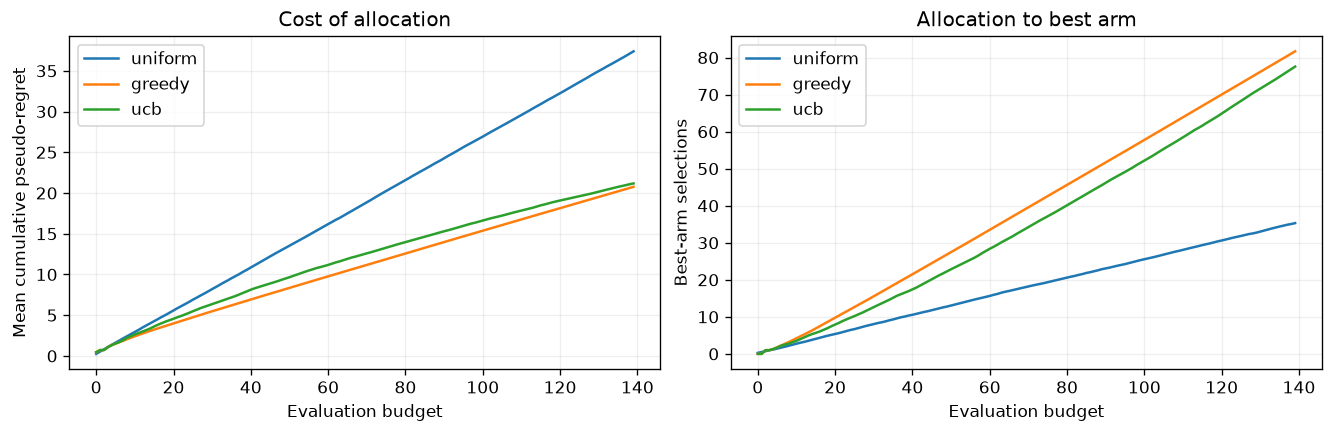

In [4]:
H=140;REPS=250
results={}
for mode in ('uniform','greedy','ucb'):
    results[mode]=[run_bandit(mode,P,H,1000+j) for j in range(REPS)]
fig,ax=plt.subplots(1,2,figsize=(11,3.5),layout='constrained')
for mode,rs in results.items():
    ax[0].plot(np.mean([r['pseudo_regret'] for r in rs],axis=0),label=mode)
    ax[1].plot(np.mean([np.cumsum(r['choices']==np.argmax(P)) for r in rs],axis=0),label=mode)
ax[0].set(xlabel='Evaluation budget',ylabel='Mean cumulative pseudo-regret',title='Cost of allocation')
ax[1].set(xlabel='Evaluation budget',ylabel='Best-arm selections',title='Allocation to best arm')
ax[0].legend();ax[1].legend();plt.show()
for mode,rs in results.items():print(mode,'final regret',round(np.mean([r['pseudo_regret'][-1] for r in rs]),2))

## 4 · Understand the exploration term visually

The UCB bonus decreases as $1/\sqrt{n_i}$ with visits, but slowly grows with $\sqrt{\log t}$ when other arms receive trials. It prevents permanently ignoring an arm merely because its earliest outcomes were unlucky.

**Predict:** Does making the exploration coefficient arbitrarily large necessarily help within a fixed budget?

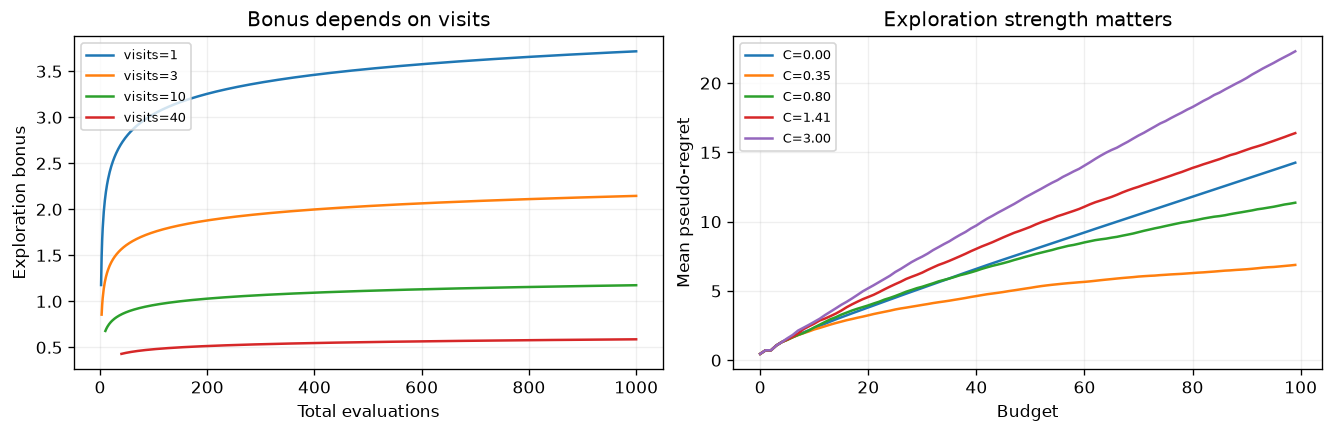

In [5]:
fig,ax=plt.subplots(1,2,figsize=(11,3.5),layout='constrained')
for n in (1,3,10,40):
    t=np.arange(max(2,n),1001)
    ax[0].plot(t,np.sqrt(2*np.log(t)/n),label=f'visits={n}')
for coeff in (0,.35,.8,np.sqrt(2),3.):
    trials=[run_bandit('ucb',P,100,3000+j,coeff) for j in range(120)]
    ax[1].plot(np.mean([r['pseudo_regret'] for r in trials],axis=0),label=f'C={coeff:.2f}')
ax[0].set(xlabel='Total evaluations',ylabel='Exploration bonus',title='Bonus depends on visits')
ax[1].set(xlabel='Budget',ylabel='Mean pseudo-regret',title='Exploration strength matters')
for a in ax:a.legend(fontsize=8)
plt.show()

## 5 · From a bandit to a tree of partial programs

The bandit has independent choices. Program synthesis is different: a chosen operation changes the **partial program** and which extensions remain available.

We use a tiny binary operation grammar with three choices in sequence. The complete program $({\tt mask,shift,mask})$ is the unique exact solution; $({\tt shift,shift,shift})$ gives an attractive but imperfect score. Every terminal program can be enumerated, giving us an **external correctness oracle** for our toy search.

**Predict:** Why is there no single universal score for selecting `mask` independent of the partial program that precedes it?

**Model boundary:** `mask` and `shift` are action labels here; no grid interpreter executes them in this lesson. The reward table isolates tree-search mechanics. Lessons 06–08 introduce actual grid semantics.

Complete candidate programs: 8


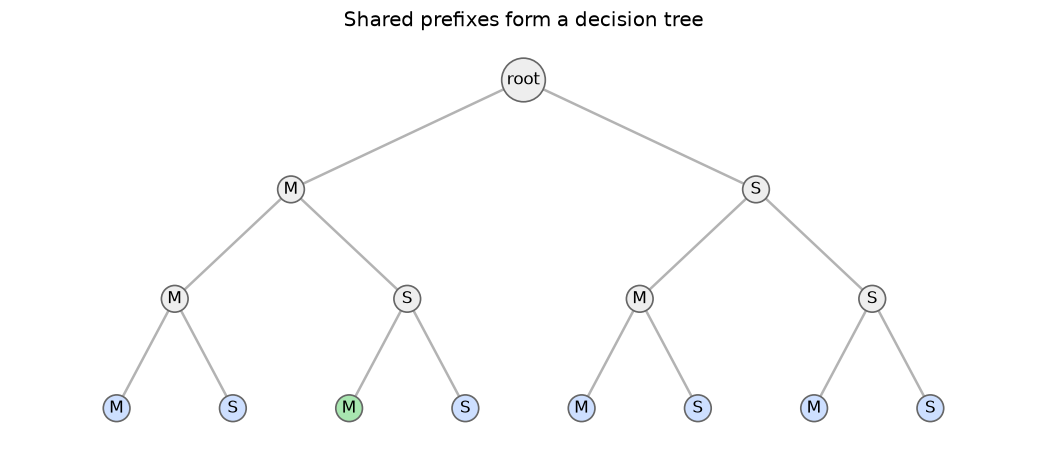

In [6]:
ACTIONS=('mask','shift')
DEPTH=3
TARGET=('mask','shift','mask')
LEAVES=list(product(ACTIONS,repeat=DEPTH))
def terminal_score(path,kind='shaped'):
    path=tuple(path)
    assert len(path)==DEPTH
    if kind=='exact':return float(path==TARGET)
    if kind=='shaped':
        return 1. if path==TARGET else (.35 if path==('shift','shift','shift') else 0.)
    if kind=='prefix':
        match=0
        for a,b in zip(path,TARGET):
            if a!=b:break
            match+=1
        return 1. if match==DEPTH else .12*match/DEPTH
    raise ValueError(kind)
assert len(LEAVES)==2**DEPTH
assert max(LEAVES,key=terminal_score)==TARGET
positions={}
for d in range(DEPTH+1):
    prefixes=sorted(set(leaf[:d] for leaf in LEAVES))
    for j,p in enumerate(prefixes):positions[p]=((j+.5)/len(prefixes),-d)
fig,ax=plt.subplots(figsize=(11,4.5))
for p,(x,y) in positions.items():
    if p:
        px,py=positions[p[:-1]]
        ax.plot([px,x],[py,y],color='0.7')
    color='#a8e6b0' if p==TARGET else ('#cddfff' if len(p)==DEPTH else '#eeeeee')
    ax.text(x,y,p[-1][0].upper() if p else 'root',ha='center',va='center',
            bbox=dict(boxstyle='circle',fc=color,ec='0.4'))
ax.set(xlim=(-.05,1.05),ylim=(-3.4,.4),title='Shared prefixes form a decision tree')
ax.axis('off');plt.show()
print('Complete candidate programs:',len(LEAVES))

## 6 · Four phases of MCTS

**Selection:** move through already-expanded actions according to a tree policy.

**Expansion:** create a new child for a legal, untried action.

**Simulation:** finish a partial program using a rollout policy and evaluate its terminal reward.

**Backpropagation:** add the reward to the visit/reward statistics of every node visited during the current iteration.

For fully expanded states, **UCT** selects

$$a^*=\arg\max_a\left(Q(s,a)+C\sqrt{\frac{\log N(s)}{N(s,a)}}\right).$$

Here $Q$ is empirical *rollout return*, not a probability that the incomplete program is logically correct. We avoid division by zero by expanding untried actions first. The final decision rule need not include the optimistic bonus.

**Predict:** Does evaluating a complete rollout imply that every prefix on its path is useful?

In [7]:
@dataclass
class Node:
    path:tuple
    children:dict=field(default_factory=dict)
    visits:int=0
    reward_sum:float=0.
    @property
    def mean(self):
        return self.reward_sum/self.visits if self.visits else 0.

def best_uct_child(node,C):
    assert node.children and all(ch.visits>0 for ch in node.children.values())
    return max(node.children.values(),
               key=lambda ch:ch.mean+C*np.sqrt(np.log(node.visits)/ch.visits))

def run_mcts(steps=150,seed=0,C=1.15,kind='shaped',rollout='uniform'):
    gen=np.random.default_rng(seed)
    root=Node(())
    traces=[]
    for _ in range(steps):
        node=root;visited=[node]
        while len(node.path)<DEPTH:
            untried=[a for a in ACTIONS if a not in node.children]
            if untried:
                action=untried[int(gen.integers(len(untried)))]
                child=Node(node.path+(action,))
                node.children[action]=child
                node=child;visited.append(node)
                break
            node=best_uct_child(node,C)
            visited.append(node)
        program=list(node.path)
        while len(program)<DEPTH:
            if rollout=='uniform':
                program.append(ACTIONS[int(gen.integers(2))])
            elif rollout=='mask_bias':
                program.append('mask' if gen.random()<.8 else 'shift')
            else:raise ValueError(rollout)
        reward=terminal_score(program,kind)
        for v in visited:
            v.visits+=1
            v.reward_sum+=reward
        traces.append((tuple(program),reward,visited[1].path[0]))
    return root,traces

root,traces=run_mcts(200,SEED)
assert root.visits==200
assert sum(ch.visits for ch in root.children.values())==root.visits
assert np.isclose(root.reward_sum,sum(r for _,r,_ in traces))
print('Root visits:',root.visits)
print({k:(v.visits,round(v.mean,3)) for k,v in root.children.items()})

Root visits: 200
{'mask': (193, 0.933), 'shift': (7, 0.05)}


### Follow one backup by hand

For an edge with $N=2$ visits and accumulated reward $W=0.35$, the mean is $Q=0.175$. A new successful simulation adds one visit and one reward: $N=3$, $W=1.35$, $Q=0.45$. Every **stored node on the selected/expanded path** gets this update. Rollout-only prefixes are not inserted into our tree or updated as nodes.

The heatmap below shows precisely which stored prefixes received credit in the first eight simulations. A visit count is a record of sampled evidence, not a count of unique programs. Search backup updates statistics; neural backpropagation differentiates a loss with respect to weights.

Executed rollouts: [(('shift', 'shift', 'mask'), 0.0), (('mask', 'mask', 'mask'), 0.0), (('shift', 'shift', 'shift'), 0.35), (('mask', 'mask', 'mask'), 0.0), (('shift', 'mask', 'mask'), 0.0), (('mask', 'shift', 'mask'), 1.0), (('mask', 'shift', 'mask'), 1.0), (('mask', 'shift', 'shift'), 0.0)]


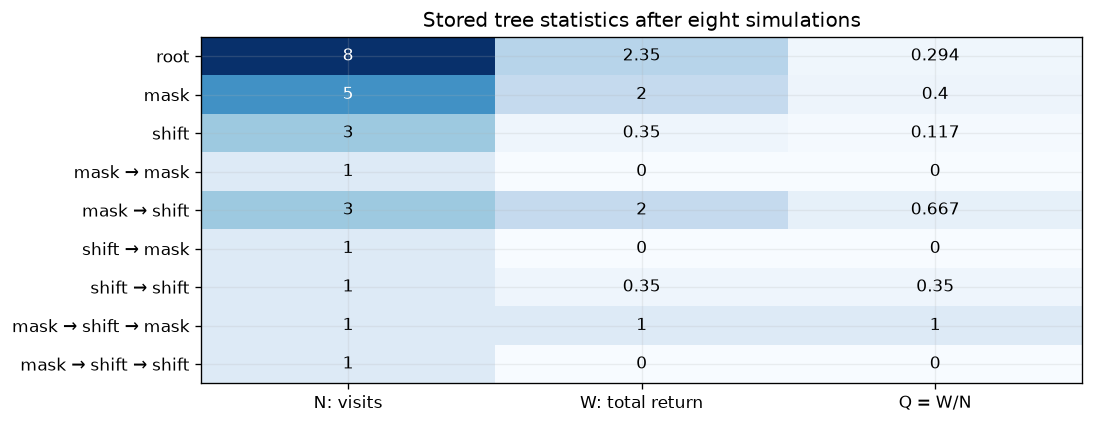

In [8]:
trace_root, short_trace = run_mcts(8, seed=17)
stored = []
def collect_nodes(node):
    stored.append(node)
    for child in node.children.values(): collect_nodes(child)
collect_nodes(trace_root)
stored.sort(key=lambda node: (len(node.path), node.path))
fig, ax = plt.subplots(figsize=(9, max(3, .38*len(stored))), layout='constrained')
table = np.array([[node.visits, node.reward_sum, node.mean] for node in stored])
ax.imshow(table, cmap='Blues', aspect='auto')
ax.set(xticks=range(3), xticklabels=['N: visits', 'W: total return', 'Q = W/N'],
       yticks=range(len(stored)),
       yticklabels=['root' if not node.path else ' → '.join(node.path) for node in stored],
       title='Stored tree statistics after eight simulations')
for i in range(len(stored)):
    for j in range(3): ax.text(j, i, f'{table[i,j]:.3g}', ha='center', va='center',
                              color='white' if table[i,j]>table.max()/2 else 'black')
plt.show()
print('Executed rollouts:', [(p, reward) for p, reward, _ in short_trace])
assert trace_root.visits == 8


## 7 · Watch attention and program coverage evolve

MCTS is not a synonym for exhaustive enumeration: it can revisit the same full program, while its upper tree levels redistribute sampling according to observed returns.

**Predict:** What is the difference between an *unexplored child node* and an *unobserved terminal program*? Why does the distinction matter for duplicate handling?

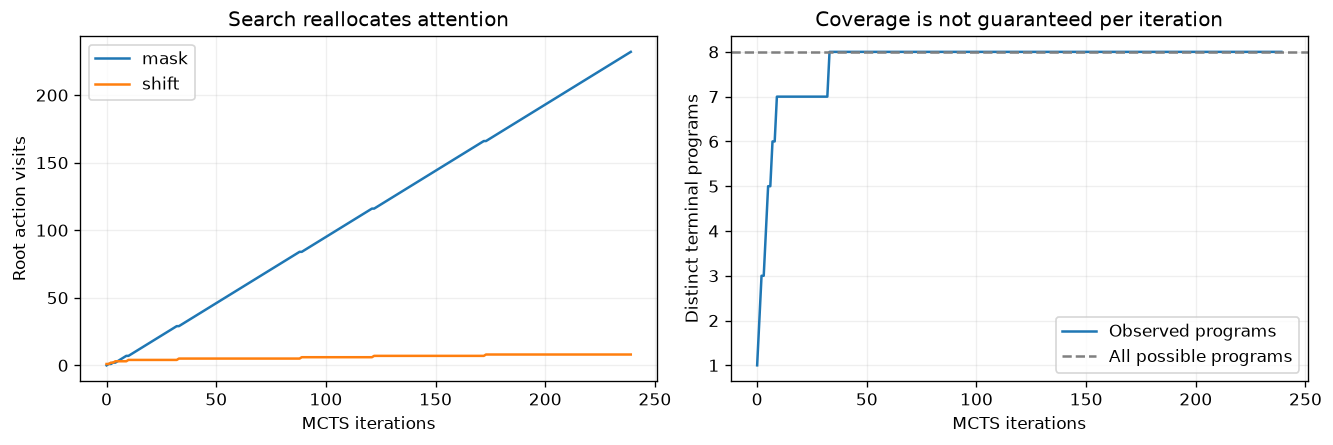

In [9]:
root,traces=run_mcts(240,seed=17)
visits=np.array([[sum(x[2]==a for x in traces[:t]) for a in ACTIONS] for t in range(1,len(traces)+1)])
unique=[];seen=set()
for p,_,_ in traces:seen.add(p);unique.append(len(seen))
fig,ax=plt.subplots(1,2,figsize=(11,3.6),layout='constrained')
for i,a in enumerate(ACTIONS):ax[0].plot(visits[:,i],label=a)
ax[0].set(xlabel='MCTS iterations',ylabel='Root action visits',title='Search reallocates attention')
ax[0].legend()
ax[1].plot(unique,label='Observed programs')
ax[1].axhline(len(LEAVES),ls='--',color='gray',label='All possible programs')
ax[1].set(xlabel='MCTS iterations',ylabel='Distinct terminal programs',title='Coverage is not guaranteed per iteration')
ax[1].legend();plt.show()
assert max(unique)<=len(LEAVES)

## 8 · Check the algorithm against an exhaustive oracle

With eight terminal programs, brute force finds the global optimum without needing search. We can use that as a **test** for this educational implementation. On harder problems, the lack of an oracle is precisely the difficulty.

We verify the bookkeeping identities and discover the target with a generous evaluation budget. This is not a finite-budget success guarantee for every seed.

In [10]:
brute_force=max(LEAVES,key=terminal_score)
root,trace=run_mcts(3000,seed=3)
assert brute_force==TARGET
assert root.visits==len(trace)
assert np.isclose(root.reward_sum,sum(r for _,r,_ in trace))
assert any(p==TARGET for p,_,_ in trace)
print('Brute force optimum:',brute_force)
print('Found by MCTS:',TARGET in {p for p,_,_ in trace})
print('Binary programs at depth 25:',2**25)

Brute force optimum: ('mask', 'shift', 'mask')
Found by MCTS: True
Binary programs at depth 25: 33554432


## 9 · Sparse and misleading terminal rewards

A program often obtains a nonzero reward only after a *sequence* of operations. Partial programs may be uninformative or misleading. We compare:

- `exact`: only the true terminal program scores.
- `shaped`: an incorrect program yields a tempting partial return.
- `prefix`: a constructed prefix-alignment proxy yields intermediate signal.

**Caution:** such prefix feedback is available here only because we deliberately constructed the target. On an ARC task, the hidden program is not known. A training-grid mismatch score is not automatically a trustworthy proxy for held-out generalization.

**Predict:** Is the reward that maximizes average simulated return necessarily the reward that most quickly finds an exact solution?

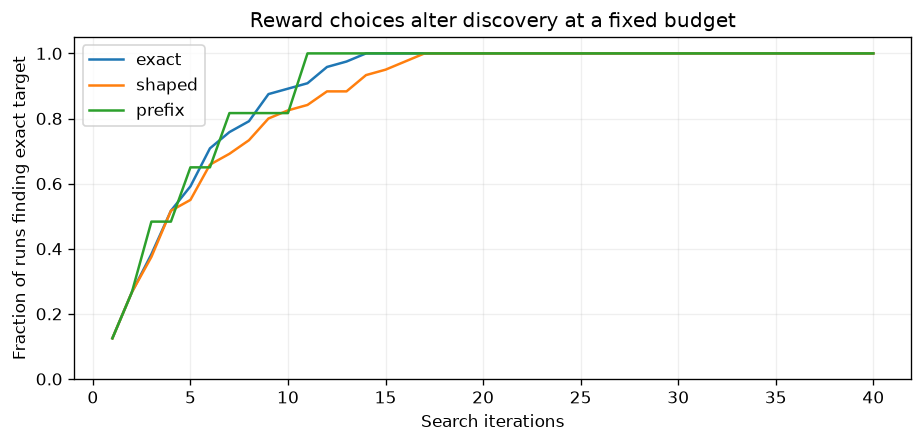

In [11]:
B=40;REPS=120
fig,ax=plt.subplots(figsize=(9,3.7))
for kind in ('exact','shaped','prefix'):
    first=[]
    for seed in range(REPS):
        _,tr=run_mcts(B,seed=200+seed,kind=kind)
        first.append(next((i+1 for i,(p,_,_) in enumerate(tr) if p==TARGET),B+1))
    curve=[np.mean(np.array(first)<=t) for t in range(1,B+1)]
    ax.plot(range(1,B+1),curve,label=kind)
ax.set(xlabel='Search iterations',ylabel='Fraction of runs finding exact target',
       ylim=(0,1.05),title='Reward choices alter discovery at a fixed budget')
ax.legend();plt.show()

## 10 · Cost-aware search and unequal branching factors

Our toy defines each rollout as one unit of work. In a real synthesis engine, the following budgets differ:

- attempted generations vs accepted unique genes,
- number of candidate executions,
- number of GP/SP component comparisons,
- CPU/GPU time and peak memory,
- and training versus held-out exact solve rates.

Operators also differ in branching factor and legal source combinations. Choosing the same *number* of attempts for each method may be unfair when one repeatedly tests expensive binary source combinations.

**Predict:** Can the action with the highest usefulness probability be inferior under a wall-time budget?

Best raw success: expensive segment
Best useful-return rate: cheap rotate


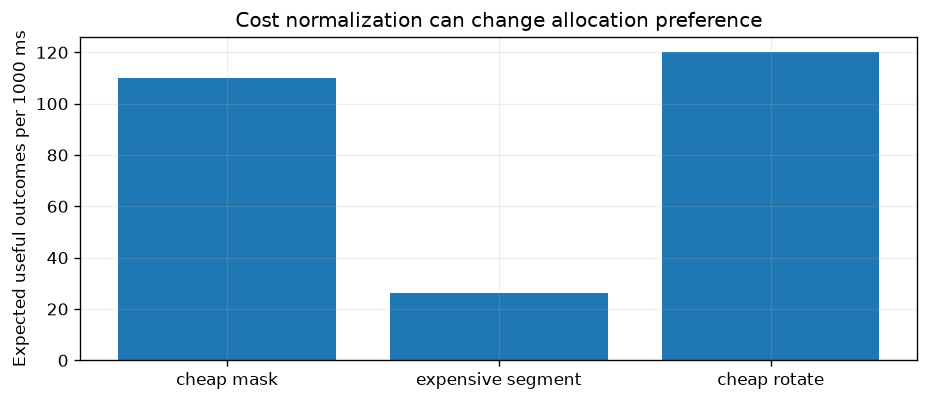

In [12]:
labels=['cheap mask','expensive segment','cheap rotate']
success=np.array([.22,.47,.18])
milliseconds=np.array([2.,18.,1.5])
throughput=1000*success/milliseconds
fig,ax=plt.subplots(figsize=(9,3.5))
ax.bar(labels,throughput)
ax.set(ylabel='Expected useful outcomes per 1000 ms',
       title='Cost normalization can change allocation preference')
plt.show()
print('Best raw success:',labels[int(np.argmax(success))])
print('Best useful-return rate:',labels[int(np.argmax(throughput))])
assert np.argmax(success)!=np.argmax(throughput)

## 11 · Delayed rewards and backward credit

When a sequence of transformations finally helps solve a task, one can propagate credit backward. A simple heuristic assigns $\gamma^d$ of terminal credit to an ancestor $d$ steps away.

This offers a **transferable signal** for ancestors, but is not an unbiased estimator of counterfactual importance. If one operation participates in many irrelevant lineages, naive pooling may over-credit it. The difference between observing a successful descendant and proving an operation was essential is substantial.

**Predict:** Why might treating each operation name as one global arm obscure source-dependent utility?

{'shape': np.float64(0.522), 'crop': np.float64(0.6141), 'mask': np.float64(0.7225), 'shift': np.float64(0.85), 'paint': np.float64(1.0)}


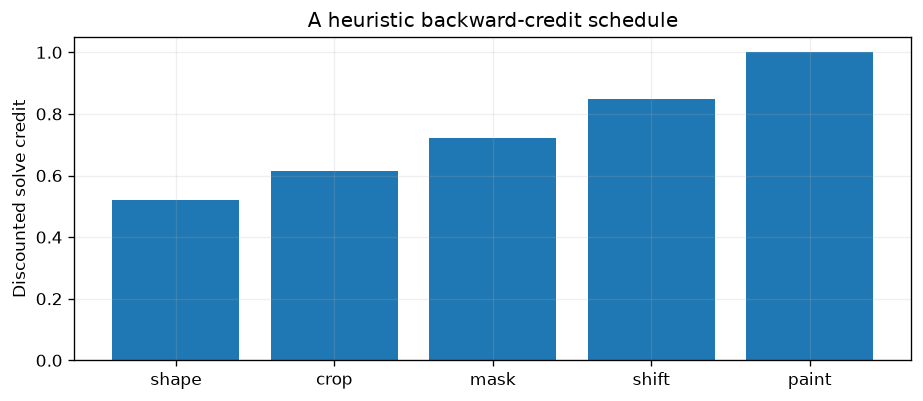

In [13]:
lineage=['shape','crop','mask','shift','paint'];gamma=.85
credit=[gamma**(len(lineage)-1-i) for i in range(len(lineage))]
fig,ax=plt.subplots(figsize=(9,3.5))
ax.bar(lineage,credit);ax.set(ylim=(0,1.05),ylabel='Discounted solve credit',
                             title='A heuristic backward-credit schedule')
plt.show()
print(dict(zip(lineage,np.round(credit,4))))
assert np.isclose(credit[-1],1)

## 12 · Relating MCTS to the real Grammar-UCT architecture

Conceptual correspondence:

| Search concept | Symbolic-search interpretation |
|---|---|
| State | Partial program plus task-specific available genes |
| Action | Legal operation, sources, and parameters |
| Transition | Execute and potentially admit generated gene(s) |
| Terminal reward | Exact task solve or a bounded diagnostic reward |
| Prior statistics | Learned operation and source-phenotype preferences |
| Depth | Composition lineage, not always identical to gene index |
| Deduplication | Semantic equivalence on observed examples; identity may still matter |
| Budget | Accepted generations, attempted actions, executions, or runtime |

A **persistent cross-task Grammar-UCT** that pools operation/phenotype statistics across tasks is *not automatically identical* to textbook single-tree MCTS. Its arm rewards are contextual, the legal action set evolves, and discounted intermediate solve credit need not be a Monte Carlo return. Both approaches share the idea of balancing observed utility and incomplete exploration.

A sensible comparison tests uniform sampling, UCB/UCT, and learned guidance under **equal accepted generations and equal wall clock time**. Record candidate executions separately to diagnose hidden overhead.

## 13 · Failure modes and assumptions

1. **Stationarity breaks:** changing task/source distributions can make historical arm averages misleading.
2. **Sparse rewards:** an important prefix can look worthless until its descendants are constructed.
3. **Wrong grammar:** no allocation method can generate a transformation absent from the language.
4. **Reward mismatch:** training demonstrations, structural proxies, and held-out exact success are different objectives.
5. **Dependent trials:** repeatedly expanding nearby programs violates the simple independent-arm model.
6. **Pruning/duplication:** candidate distribution changes as the pool evolves.
7. **Selection bias:** recorded successes overrepresent what the search policy chose to evaluate.

These are reasons to *measure* rather than assume UCT superiority. The standard UCB1 regret theorem relies on assumptions absent from general program search, and the UCT formula's appearance alone establishes no ARC guarantee.

## 14 · Forward bridge: why learn a search policy?

Next lesson **05** will replace generic priors with learned guidance:

- a **policy** model predicting promising legal actions given demonstrations and a partial program;
- a **value** model predicting continuation usefulness under a specified horizon/rollout policy;
- later, in lesson **06**, **embeddings** for program structure and execution behavior.

These should be trained and evaluated separately. Imitating the existing search can reproduce its blind spots; a value trained on partial training fit may not predict an exact test solve.

The goal is not to decorate MCTS with a network. It is to test whether learned information saves computations under a matched budget.

## 15 · Exercises — predict, alter, and verify

1. At $t=100$, compare UCB1 scores for $(n,\hat\mu)=(4,.2)$ and $(40,.5)$. Does a UCB score have to stay below one?
2. Set UCB's exploration coefficient to zero. Explain why the first few attempts still explore.
3. Change arm probabilities halfway through the horizon. How do stale counts affect selection?
4. Modify MCTS to forbid `shift` after `mask`. Enumerate legal leaves and check that rollout and expansion preserve legality.
5. Change `DEPTH` to 5 and choose a new target. What additional code or tests must change?
6. Explain why UCT's child mean is not necessarily a Bayesian posterior about correctness.
7. With $\gamma=.85$, compute discounted solve credit at distances 1 through 4.
8. Compare MCTS with uniform enumeration at exactly the same number of complete-program executions. Measure discovery rate across 200 seeds.
9. Design an ARC experiment comparing uniform, UCT, and neural-guided search without training/evaluation contamination.

Attempt several exercises before reading the solutions.

## 16 · Worked solutions and reconstruction checklist

1. The first is $.2+\sqrt{2\ln(100)/4}\approx1.717$, the second $.5+\sqrt{2\ln(100)/40}\approx.980$. The optimistic score can exceed 1.
2. `choose_arm` explicitly samples unseen arms first; with coefficient zero, the remaining policy is greedy.
3. Long-run counts can delay adaptation to a new best arm. Sliding-window or discounted statistics can help but introduce new hyperparameters.
4. Define `legal_actions(prefix)` and reuse it in brute-force enumeration, expansion, and rollout. Assert every sampled terminal path is legal.
5. Update target length, scores, plots, and any synthetic proxy defined only for depth three.
6. The mean averages returns from past simulations conditioned on node visits and a changing continuation policy; it is not a normalized model posterior.
7. $.85$, $.7225$, $.614125$, $.52200625$.
8. Include repeated runs, fixed budgets and seeds; report exact-discovery fraction plus uncertainty, not a single attractive trajectory.
9. Fix grammar and splits, tune on training/validation only, compare exact unseen-task solves at matched compute and account for rejected duplicate proposals.

**Reconstruct from memory:** (a) count/mean per arm, (b) UCB bonus, (c) prefix tree and legal actions, (d) selection-expansion-rollout-backpropagation, (e) exhaustive oracle for a small test, (f) controlled experiment matching search budgets.

### Primary reading
- Auer, Cesa-Bianchi & Fischer (2002), *Finite-time Analysis of the Multiarmed Bandit Problem*.
- Kocsis & Szepesvári (2006), *Bandit Based Monte-Carlo Planning*.
- Browne et al. (2012), *A Survey of Monte Carlo Tree Search Methods*.
- Sutton & Barto (2018), *Reinforcement Learning: An Introduction*, chapter 2.
- Silver et al. (2017), *Mastering the game of Go without human knowledge* (neural policy/value-guided search).

**Scope:** an original teaching implementation, not an ARC benchmark, production-grade MCTS library, or guarantee of optimal search.